In this project, we aim to analyze customer behavior and build a predictive model to identify churn. Customer churn—the likelihood that a customer will stop using a service—is a critical metric for businesses, as retaining existing customers is often more cost-effective than acquiring new ones.

The workflow begins with data preprocessing, where we clean the dataset, handle missing values, and engineer relevant features to better represent customer behavior. We then perform exploratory data analysis (EDA) to uncover patterns and relationships between variables that may influence churn.

Following this, we apply machine learning models to predict whether a customer is likely to churn. Model performance is evaluated using appropriate metrics such as accuracy, F1-score, and ROC-AUC to ensure a balanced and reliable assessment. The ultimate goal is to build a model that not only performs well statistically but also provides meaningful insights that can support business decision-making.


In [30]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.metrics import roc_curve
from sklearn.metrics import confusion_matrix
from lightgbm import LGBMClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time 
import numpy as np


We began by checking the dataset for duplicates and missing values to ensure data quality. After identifying gaps, we merged the relevant datasets into a single dataframe and filled in missing values where necessary. We then created new features to better capture meaningful patterns in the data. Categorical variables were encoded using appropriate techniques, such as one-hot encoding, to make them suitable for machine learning models while avoiding multicollinearity. The target variable was also properly defined by converting churn into a binary indicator. Finally, the data was split into training and testing sets, and scaling was applied to numerical features where appropriate to improve model performance and stability.

In [31]:




contract_data = pd.read_csv("datasets/final_provider/contract.csv")
personal_data = pd.read_csv("datasets/final_provider/personal.csv")
internet_data = pd.read_csv("datasets/final_provider/internet.csv")
phone_data = pd.read_csv("datasets/final_provider/phone.csv")


print("=== Contract Data Columns ===")
print(contract_data.columns)

print("\n=== Personal Data Columns ===")
print(personal_data.columns)

print("\n=== Internet Data Columns ===")
print(internet_data.columns)

print("\n=== Phone Data Columns ===")
print(phone_data.columns)

=== Contract Data Columns ===
Index(['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges'],
      dtype='object')

=== Personal Data Columns ===
Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents'], dtype='object')

=== Internet Data Columns ===
Index(['customerID', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'],
      dtype='object')

=== Phone Data Columns ===
Index(['customerID', 'MultipleLines'], dtype='object')


In [32]:
print(contract_data['EndDate'])

0                        No
1                        No
2       2019-12-01 00:00:00
3                        No
4       2019-11-01 00:00:00
               ...         
7038                     No
7039                     No
7040                     No
7041    2019-11-01 00:00:00
7042                     No
Name: EndDate, Length: 7043, dtype: object


In [33]:

print("contract_data nulls:\n", contract_data.isnull().sum(), "\n")

print("personal_data nulls:\n", personal_data.isnull().sum(), "\n")

print("internet_data nulls:\n", internet_data.isnull().sum(), "\n")

print("phone_data nulls:\n", phone_data.isnull().sum(), "\n")


contract_data nulls:
 customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
dtype: int64 

personal_data nulls:
 customerID       0
gender           0
SeniorCitizen    0
Partner          0
Dependents       0
dtype: int64 

internet_data nulls:
 customerID          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
dtype: int64 

phone_data nulls:
 customerID       0
MultipleLines    0
dtype: int64 



In [34]:
print(contract_data.duplicated().sum())
print(personal_data.duplicated().sum())
print(internet_data.duplicated().sum())
print(phone_data.duplicated().sum())

0
0
0
0


In [35]:
df = contract_data.merge(personal_data, on='customerID', how='left')
df = df.merge(internet_data, on='customerID', how='left') 
df = df.merge(phone_data, on='customerID', how='left')

print("Null values per column:")
print(df.isnull().sum())
print(df.shape)




Null values per column:
customerID             0
BeginDate              0
EndDate                0
Type                   0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
InternetService     1526
OnlineSecurity      1526
OnlineBackup        1526
DeviceProtection    1526
TechSupport         1526
StreamingTV         1526
StreamingMovies     1526
MultipleLines        682
dtype: int64
(7043, 20)


In [36]:
internet_cols = [
    'InternetService', 'OnlineSecurity', 'OnlineBackup',
    'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies'
]

phone_cols = ['MultipleLines']

df[internet_cols] = df[internet_cols].fillna('No')
df[phone_cols] = df[phone_cols].fillna('No')
print("Null values per column:")
print(df.isnull().sum())
print(df.shape)

Null values per column:
customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MultipleLines       0
dtype: int64
(7043, 20)


In [37]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

df['TotalCharges'] = df['TotalCharges'].fillna(0)
print("Null values per column:")
print(df.isnull().sum())
print(df.shape)

Null values per column:
customerID          0
BeginDate           0
EndDate             0
Type                0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
MultipleLines       0
dtype: int64
(7043, 20)


In [38]:
df['BeginDate'] = pd.to_datetime(df['BeginDate'])



df['churn'] = (df['EndDate'] != 'No').astype(int)


snapshot_date = df['BeginDate'].max()

df['tenure_days'] = (snapshot_date - df['BeginDate']).dt.days

# Numeric fix
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
# print(df)
print(df.columns)


Index(['customerID', 'BeginDate', 'EndDate', 'Type', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'gender',
       'SeniorCitizen', 'Partner', 'Dependents', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'MultipleLines', 'churn',
       'tenure_days'],
      dtype='object')


In [39]:
print(df.head())
print(df.info())
print(df.shape)
print(df.describe())


   customerID  BeginDate              EndDate            Type  \
0  7590-VHVEG 2020-01-01                   No  Month-to-month   
1  5575-GNVDE 2017-04-01                   No        One year   
2  3668-QPYBK 2019-10-01  2019-12-01 00:00:00  Month-to-month   
3  7795-CFOCW 2016-05-01                   No        One year   
4  9237-HQITU 2019-09-01  2019-11-01 00:00:00  Month-to-month   

  PaperlessBilling              PaymentMethod  MonthlyCharges  TotalCharges  \
0              Yes           Electronic check           29.85         29.85   
1               No               Mailed check           56.95       1889.50   
2              Yes               Mailed check           53.85        108.15   
3               No  Bank transfer (automatic)           42.30       1840.75   
4              Yes           Electronic check           70.70        151.65   

   gender  SeniorCitizen  ... InternetService OnlineSecurity OnlineBackup  \
0  Female              0  ...             DSL            

In [40]:
churn = df['churn']
features = df.drop(['churn', 'customerID', 'EndDate', 'BeginDate'], axis=1)
print(features.columns)


Index(['Type', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines',
       'tenure_days'],
      dtype='object')


In [41]:

print(churn.head())




0    0
1    0
2    1
3    0
4    1
Name: churn, dtype: int64


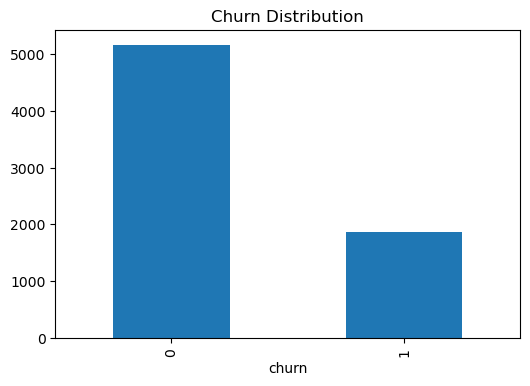

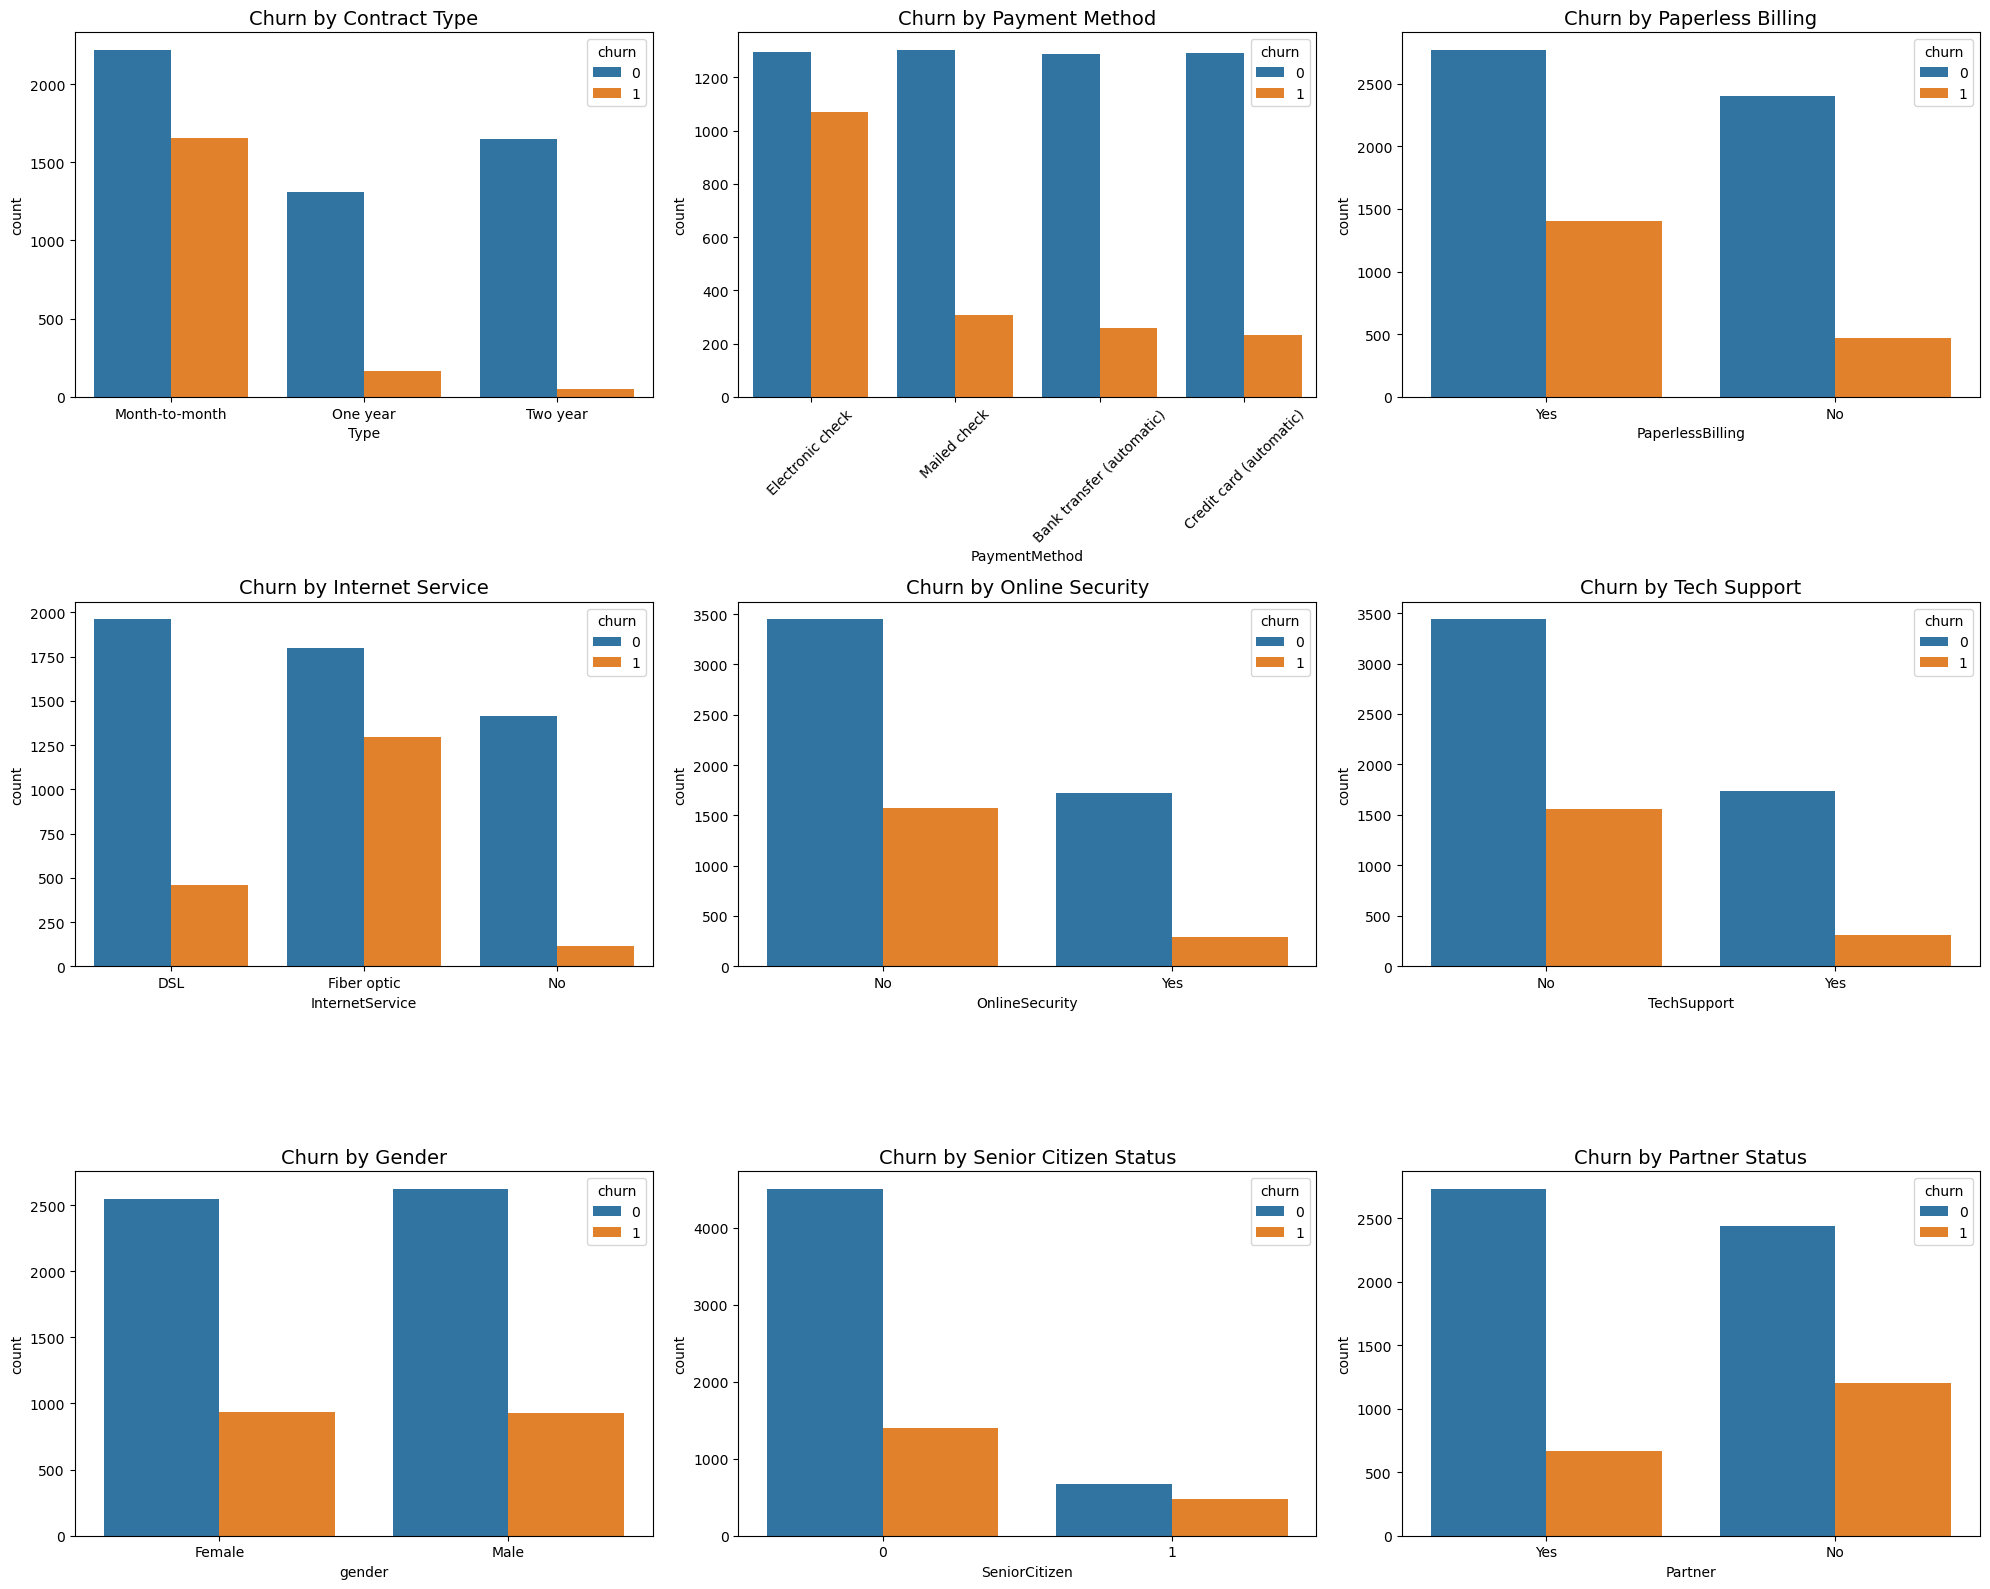

In [42]:
df['churn'].value_counts(normalize=True)
plt.figure(figsize=(6, 4))
df['churn'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.show()



fig, axes = plt.subplots(3, 3, figsize=(20, 16))

# Row 1: Contract and Payment Features (most impactful)
sns.countplot(data=df, x='Type', hue='churn', ax=axes[0,0])
axes[0,0].set_title('Churn by Contract Type', fontsize=14)

sns.countplot(data=df, x='PaymentMethod', hue='churn', ax=axes[0,1])
axes[0,1].set_title('Churn by Payment Method', fontsize=14)
axes[0,1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='PaperlessBilling', hue='churn', ax=axes[0,2])
axes[0,2].set_title('Churn by Paperless Billing', fontsize=14)

# Row 2: Service Features
sns.countplot(data=df, x='InternetService', hue='churn', ax=axes[1,0])
axes[1,0].set_title('Churn by Internet Service', fontsize=14)

sns.countplot(data=df, x='OnlineSecurity', hue='churn', ax=axes[1,1])
axes[1,1].set_title('Churn by Online Security', fontsize=14)

sns.countplot(data=df, x='TechSupport', hue='churn', ax=axes[1,2])
axes[1,2].set_title('Churn by Tech Support', fontsize=14)

# Row 3: Demographics (including gender)
sns.countplot(data=df, x='gender', hue='churn', ax=axes[2,0])
axes[2,0].set_title('Churn by Gender', fontsize=14)

sns.countplot(data=df, x='SeniorCitizen', hue='churn', ax=axes[2,1])
axes[2,1].set_title('Churn by Senior Citizen Status', fontsize=14)

sns.countplot(data=df, x='Partner', hue='churn', ax=axes[2,2])
axes[2,2].set_title('Churn by Partner Status', fontsize=14)

plt.tight_layout()
plt.show()


The analysis indicates that churn is primarily driven by contract type, payment method, and service-related features. Customers on month-to-month contracts, those using electronic check payments, and those lacking additional services such as online security and tech support exhibit significantly higher churn rates. Fiber optic users also demonstrate elevated churn, potentially reflecting higher expectations or pricing sensitivity. Additionally, senior customers, paperless billing users, and those without partners show moderately higher churn rates. In contrast, gender does not appear to have a meaningful impact on churn behavior.

In [43]:

categorical_cols = features.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

# Apply get_dummies to all categorical columns at once
features_encoded = pd.get_dummies(features, columns=categorical_cols, drop_first=True)
print("Shape before encoding:", features.shape)
print("Shape after encoding:", features_encoded.shape)



Categorical columns to encode: ['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']
Shape before encoding: (7043, 18)
Shape after encoding: (7043, 22)


In [44]:

X_train, X_test, y_train, y_test = train_test_split(features_encoded, churn, test_size=0.2, random_state=42)



In [45]:
num_cols = ['MonthlyCharges', 'TotalCharges', 'tenure_days']

scaler = StandardScaler()
features[num_cols] = scaler.fit_transform(features[num_cols])

In [46]:
print(features.head)

<bound method NDFrame.head of                 Type PaperlessBilling              PaymentMethod  \
0     Month-to-month              Yes           Electronic check   
1           One year               No               Mailed check   
2     Month-to-month              Yes               Mailed check   
3           One year               No  Bank transfer (automatic)   
4     Month-to-month              Yes           Electronic check   
...              ...              ...                        ...   
7038        One year              Yes               Mailed check   
7039        One year              Yes    Credit card (automatic)   
7040  Month-to-month              Yes           Electronic check   
7041  Month-to-month              Yes               Mailed check   
7042        Two year              Yes  Bank transfer (automatic)   

      MonthlyCharges  TotalCharges  gender  SeniorCitizen Partner Dependents  \
0          -1.160323     -0.992611  Female              0     Yes        

In [47]:
df[num_cols].describe()

,MonthlyCharges,TotalCharges,tenure_days
count,7043.000000,7043.000000,7043.000000
mean,64.761692,2279.734304,1006.457050
std,30.090047,2266.794470,736.596428
min,18.250000,0.000000,0.000000
25%,35.500000,398.550000,306.000000
50%,70.350000,1394.550000,883.000000
75%,89.850000,3786.600000,1706.000000
max,118.750000,8684.800000,2314.000000


In [48]:
# First, let's identify all categorical columns
categorical_cols = features.select_dtypes(include=['object']).columns.tolist()
print("Categorical columns to encode:", categorical_cols)

# Apply get_dummies to all categorical columns at once
features_encoded = pd.get_dummies(features, columns=categorical_cols, drop_first=True)
print("Shape before encoding:", features.shape)
print("Shape after encoding:", features_encoded.shape)

Categorical columns to encode: ['Type', 'PaperlessBilling', 'PaymentMethod', 'gender', 'Partner', 'Dependents', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'MultipleLines']
Shape before encoding: (7043, 18)
Shape after encoding: (7043, 22)


Logistic Regression train run time: 0.0694 seconds
Accuracy: 0.8112136266855926
F1: 0.6017964071856288


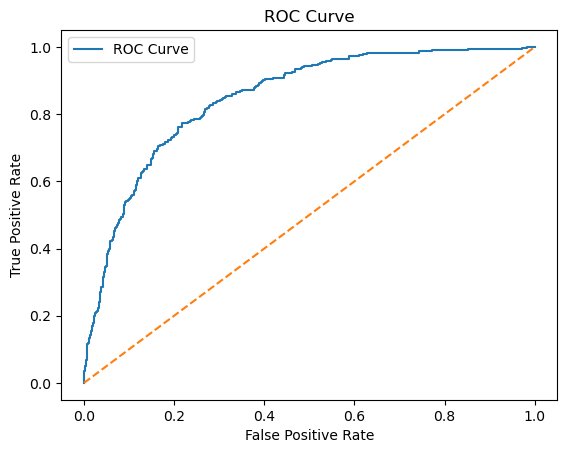

ROC-AUC: 0.848453010651402
Confusion matrix: [[942  94]
 [172 201]]
CV F1: 0.5592230285366895
Logistic Regression inference run time: 0.4449 seconds


In [53]:
start_time = time.time()



model = LogisticRegression(
    random_state=12345,
    solver='liblinear'
)
model.fit(X_train, y_train)

end_time = time.time()
logistic_regression_train_time = end_time - start_time

print(f"Logistic Regression train run time: {round(logistic_regression_train_time, 4)} seconds")

start_time = time.time()

y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print('Confusion matrix:', confusion_matrix(y_test, y_pred))
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
print("CV F1:", cv_scores.mean())
end_time = time.time()
logistic_regression_inference_time = end_time - start_time
print(f"Logistic Regression inference run time: {round(logistic_regression_inference_time, 4)} seconds")



Decision tree train time: 0.0493 seconds
Accuracy: 0.8523775727466288
f1 score 0.7204301075268817


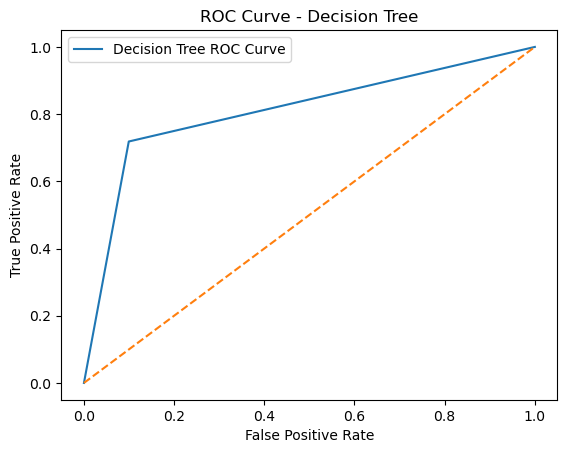

ROC-AUC: 0.8095389050482884
Confusion matrix: [[933 103]
 [105 268]]
CV F1: 0.6688396245433309
Decision tree inference time: 0.3653 seconds


In [54]:

start_time = time.time()
model = DecisionTreeClassifier(random_state=12345)
model.fit(X_train, y_train)
end_time = time.time()
decision_tree_train_time = end_time - start_time
print(f"Decision tree train time: {round(decision_tree_train_time, 4)} seconds")
start_time = time.time()

y_pred = model.predict(X_test)

# Evaluate
print("Accuracy:", accuracy_score(y_test, y_pred))
predicted_valid = model.predict(X_test)
probabilities_valid = model.predict_proba(X_test)
probabilities_one_valid = probabilities_valid[:, 1]
# <write code here >
print('f1 score', f1_score(y_test, predicted_valid))
auc_roc = roc_auc_score(y_test, probabilities_one_valid)

fpr, tpr, thresholds = roc_curve(y_test, probabilities_one_valid)

plt.figure()
plt.plot(fpr, tpr, label='Decision Tree ROC Curve')
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend()
plt.show()
print("ROC-AUC:", auc_roc)
print('Confusion matrix:', confusion_matrix(y_test, y_pred))
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
print("CV F1:", cv_scores.mean())
end_time = time.time()
decision_tree_inference_time = end_time - start_time
print(f"Decision tree inference time: {round(decision_tree_inference_time, 4)} seconds")


Random forest train time: 1.5571 seconds
Random forest
f1 score 0.6594090202177294


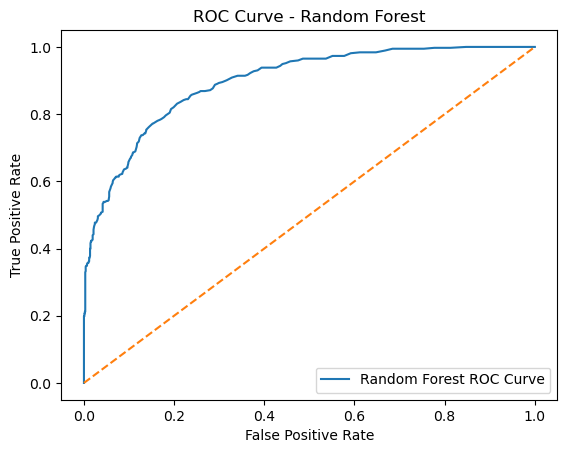

ROC-AUC: 0.896179883445299
Confusion matrix: [[978  58]
 [161 212]]
CV F1: 0.6380174648740191
Random forest inference time: 6.5261 seconds


In [55]:

start_time = time.time()


model = RandomForestClassifier(
    n_estimators=200,
    max_depth=25,
    max_features='sqrt',  # Try different feature sampling
    bootstrap=True,
    class_weight='balanced',
    random_state=12345
)




model.fit(X_train, y_train)
end_time = time.time()
random_forest_train_time = end_time - start_time
print(f"Random forest train time: {round(random_forest_train_time, 4)} seconds")
start_time = time.time()

predicted_valid = model.predict(X_test)
probabilities_valid = model.predict_proba(X_test)
probabilities_one_valid = probabilities_valid[:, 1]
print("Random forest")
print('f1 score', f1_score(y_test, predicted_valid))
auc_roc = roc_auc_score(y_test, probabilities_one_valid)
fpr, tpr, thresholds = roc_curve(y_test, probabilities_one_valid)

plt.figure()
plt.plot(fpr, tpr, label='Random Forest ROC Curve')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Random Forest')
plt.legend()
plt.show()
print("ROC-AUC:", auc_roc)
print('Confusion matrix:', confusion_matrix(y_test, predicted_valid))
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='f1')
print("CV F1:", cv_scores.mean())
end_time = time.time()
random_forest_inference_time = end_time - start_time
print(f"Random forest inference time: {round(random_forest_inference_time, 4)} seconds")


[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1496, number of negative: 4138
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001805 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 624
[LightGBM] [Info] Number of data points in the train set: 5634, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
LightGBM training time: 2.6043 seconds
LightGBM Results:
Accuracy: 0.9184
F1 Score: 0.8401


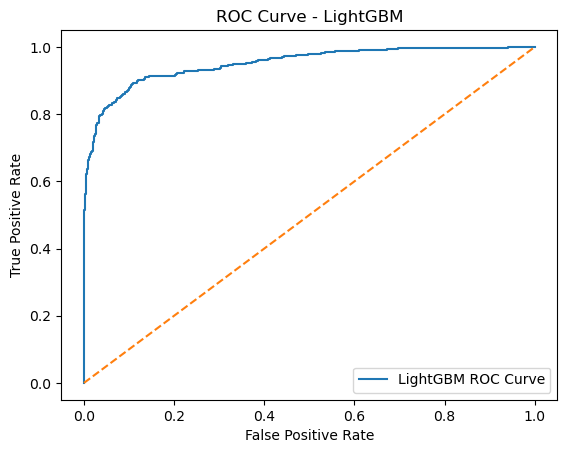

ROC-AUC: 0.9511
Confusion matrix: [[992  44]
 [ 71 302]]
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1197, number of negative: 3310
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001292 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 624
[LightGBM] [Info] Number of data points in the train set: 4507, number of used features: 22
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 1197, number of negative: 3310
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of te

In [56]:
start_time = time.time()


LGBMR = LGBMClassifier(
    learning_rate=0.03,
    n_estimators=2000,
    num_leaves=31,
    min_child_samples=30,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=0.1,
    class_weight='balanced',
    random_state=42
)

LGBMR.fit(X_train, y_train)

end_time = time.time()
lgbm_train_time = end_time - start_time

print(f"LightGBM training time: {lgbm_train_time:.4f} seconds")


# -----------------------------
# INFERENCE + METRICS
# -----------------------------
start_time = time.time()

y_pred = LGBMR.predict(X_test)
y_probs = LGBMR.predict_proba(X_test)[:, 1]

# Metrics
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_probs)

end_time = time.time()
lgbm_inference_time = end_time - start_time

print("LightGBM Results:")
print(f"Accuracy: {acc:.4f}")
print(f"F1 Score: {f1:.4f}")
fpr, tpr, thresholds = roc_curve(y_test, y_probs)

plt.figure()
plt.plot(fpr, tpr, label='LightGBM ROC Curve')
plt.plot([0, 1], [0, 1], linestyle='--')  # random baseline
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM')
plt.legend()
plt.show()
print(f"ROC-AUC: {roc:.4f}")
print('Confusion matrix:', confusion_matrix(y_test, y_pred))
cv_scores = cross_val_score(LGBMR, X_train, y_train, cv=5, scoring='f1')
print("CV F1:", cv_scores.mean())
print(f"Inference time: {lgbm_inference_time:.4f} seconds")

The results clearly show that LightGBM is the best-performing model for this churn prediction task, significantly outperforming both the baseline Logistic Regression and the other tree-based models. While the baseline Logistic Regression achieved an accuracy of 0.8112, an F1 score of 0.6018, and a ROC-AUC of 0.8485, its relatively low F1 score indicates that it struggled to balance precision and recall, meaning it was less effective at correctly identifying churners. In contrast, LightGBM delivered a much stronger performance, with an accuracy of 0.9184, an F1 score of 0.8401, and a ROC-AUC of 0.9511, representing a substantial improvement—especially in F1 score, which increased by nearly 24 percentage points. This is particularly important because churn prediction is typically an imbalanced classification problem, where correctly identifying the minority class (churners) is critical. Compared to other models, LightGBM still stands out: for example, the Decision Tree (or similar model) achieved an F1 score of 0.7204 and ROC-AUC of 0.8095, showing some ability to capture non-linear patterns but lacking overall predictive strength, while the Random Forest achieved a solid ROC-AUC of 0.8981 but a lower F1 score of 0.6563, suggesting it ranked predictions reasonably well but did not optimize the balance between precision and recall as effectively. Additionally, LightGBM achieved the highest cross-validation F1 score of 0.8003, compared to 0.5592 for Logistic Regression and lower values for the other models, indicating that its performance is not only strong on the test set but also consistent across different data splits, reducing the risk of overfitting. The superior performance of LightGBM can be explained by its use of gradient boosting, which iteratively corrects previous errors, as well as its ability to model complex non-linear relationships and interactions between features. Overall, these results demonstrate that LightGBM is the most reliable and effective model for this problem, providing the best balance of accuracy, recall, and precision, and making it the optimal choice for predicting customer churn in this dataset.


Clarifying Questions:

What is the target variable and how is churn defined?

Are there missing values, duplicates, or inconsistencies in the data?

Which features are categorical vs numerical, and which require encoding or scaling?

Is the dataset imbalanced, and do we need to address this during modeling?

Which evaluation metric is most appropriate (e.g., F1 score, ROC-AUC)?


1. Data Exploration

Inspect the dataset structure, feature types, and target distribution. Identify missing values and duplicates to understand data quality.

2. Data Preprocessing

Handle missing values, remove duplicates if necessary, and define the target variable. Encode categorical features and scale numerical variables where appropriate.

3. Exploratory Data Analysis (EDA)

Analyze relationships between features and churn using visualizations. Identify key patterns and potential predictors.

4. Model Training and Evaluation

Split the data into training and testing sets. Train models and evaluate performance using appropriate metrics.

5. Conclusions

Summarize key findings, identify important features, and provide insights or recommendations based on the results.